In [ ]:
try:
    import smolgp
except ImportError:
    %pip install -q smolgp

import time

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.linalg import expm
from scipy.integrate import quad_vec
from scipy.linalg import expm as np_expm

from smolgp.helpers import Q_from_VanLoan

jax.config.update("jax_enable_x64", True)
mpl.rc('font', family='sans serif', size=16)

(integrated_noise)=

# Derivation of the Integrated Process Noise

In the `smolgp` paper ([Rubenzahl et al. 2026](https://iopscience.iop.org/article/10.3847/1538-3881/ae4d0b)), we note (right after Eq. 36 defining the augmented process noise) that a convenient way to construct the augmented transition matrix and process noise matrix (which each depend on integrals of their unaugmented counterparts) is via the numerical method of [Van Loan (1978)](https://ecommons.cornell.edu/items/cba38b2e-6ad4-45e6-8109-0a019fe5114c). These methods are implemented in {py:func}`smolgp.helpers.Q_from_VanLoan` and {py:func}`smolgp.helpers.Phibar_from_VanLoan`, however (as we noted in the paper) for long gaps (e.g. $\Delta$ around $\sim$$10^3$ times longer than the kernel timescale) the matrix exponentials become numerically unstable, either returning finite but wildly incorrect values or NaN. Even though we reset the integral state once the next exposure is reached, other instruments which have yet to be reset can still contribute to this numerical instability.

We noted in the paper that the useful identity $\boldsymbol{Q}_k = \boldsymbol{P}_\infty - \boldsymbol{A}_k \boldsymbol{P}_\infty \boldsymbol{A}_k^T$, which defines the process noise for an instantaneous kernel, doesn't apply to integrated SSMs because the prior covariance on the integral state is undefined. However, it turns out we can still derive this identity for the integral case by circumventing that undefined issue.

In the following derivation, note that all equation numbers are with respect to the published version of the manuscript, not the arXiv version (which uses section-numbered equations).

## Definitions

First, let us define the relevant players that contribute to the augmented process noise. Recall the integral state is defined by $dz/dt = x$ (Eq. 29), giving the augmented SDE of Eqs. (30)-(31) with feedback matrix $\tilde F$ and noise effect matrix $\tilde L$. Its transition matrix is (Eq. 33)

$$
\tilde\Phi(\Delta) = \begin{pmatrix} \Phi(\Delta) & 0 \\ \bar\Phi_x(\Delta) & 1 \end{pmatrix}, \qquad
\bar\Phi(\Delta) = \int_0^\Delta \Phi(t)\, dt ,
$$

and its process noise is the block integral of Eq. (36),

$$
\tilde Q = \int_0^\Delta \tilde\Phi(t)\, \tilde L Q_c \tilde L^T\, \tilde\Phi(t)^T dt
= \begin{pmatrix}
\int \Phi L Q_c L^T \Phi^T dt & \int \Phi L Q_c L^T \bar\Phi^T dt \\
\int \bar\Phi L Q_c L^T \Phi^T dt & \int \bar\Phi L Q_c L^T \bar\Phi^T dt
\end{pmatrix} = \begin{pmatrix}
                \boldsymbol{Q}(\Delta)  &  \tilde{\boldsymbol{Q}}_{12}(\Delta) \\
                \tilde{\boldsymbol{Q}}_{12}^T(\Delta) & \tilde{\boldsymbol{Q}}_{22}(\Delta)
                \end{pmatrix}..
$$

## Why the Van Loan method is unstable over long gaps

In the paper, we describe how $\tilde{\boldsymbol{Q}}$ can either be constructed block-by-block, or all-at-once, from relevant Van Loan identities. The all-at-once method defines $\tilde{\boldsymbol{Q}} = \boldsymbol{F}_3^T \boldsymbol{G}_2$ from the matrix exponential (Eq. B13),

$$
\begin{aligned}
\exp\left[\begin{pmatrix} -\tilde{\boldsymbol{F}} & \tilde{\boldsymbol{L}} Q_c \tilde{\boldsymbol{L}}^T \\ 0 & \tilde{\boldsymbol{F}}^T \end{pmatrix}\Delta\right] = \begin{pmatrix} \boldsymbol{F}_2 & \boldsymbol{G}_2 \\ \boldsymbol{0} & \boldsymbol{F}_3 \end{pmatrix}
\end{aligned}
$$ (allatonce)

The block-by-block form (Eqs. B14-B16) realizes that the top-left block is the base process noise, which we already define analytically or via the stationary identity $\boldsymbol{Q}_k = \boldsymbol{P}_\infty - \boldsymbol{A}_k \boldsymbol{P}_\infty \boldsymbol{A}_k^T$ (Eq. 19). The other blocks come from a larger Van Loan exponential (Eq. B15), 

$$
\begin{aligned}
 \exp\left[ \begin{pmatrix}
            -\boldsymbol{F} & \boldsymbol{I}  & \boldsymbol{0}   & \boldsymbol{0} \\
            \boldsymbol{0}  & -\boldsymbol{F} & \boldsymbol{L} Q_c \boldsymbol{L}^T  & \boldsymbol{0} \\
            \boldsymbol{0}  & \boldsymbol{0}  & \boldsymbol{F}^T & \boldsymbol{I} \\
            \boldsymbol{0}  & \boldsymbol{0}  & \boldsymbol{0}   & \boldsymbol{0} \\   
            \end{pmatrix} \Delta
    \right] = 
    \begin{pmatrix}
        \boldsymbol{F}_1 & \boldsymbol{G}_1 & \boldsymbol{H}_1 & \boldsymbol{K}_1 \\
        \boldsymbol{0} & \boldsymbol{F}_2 & \boldsymbol{G}_2 & \boldsymbol{H}_2 \\
        \boldsymbol{0} & \boldsymbol{0} & \boldsymbol{F}_3 & \boldsymbol{G}_3& \\
        \boldsymbol{0} & \boldsymbol{0} & \boldsymbol{0} & \boldsymbol{F}_4 \\
    \end{pmatrix}.
\end{aligned}
$$ (blockbyblock)

which combine into

$$
\begin{aligned}
  \tilde{\boldsymbol{Q}}_{12} &= \boldsymbol{F}_3^T \boldsymbol{H}_2, \\
  \tilde{\boldsymbol{Q}}_{22} &= (\boldsymbol{F}_3^T \boldsymbol{K}_1) + (\boldsymbol{F}_3^T \boldsymbol{K}_1)^T. \nonumber \\
\end{aligned}
$$ (Qblocks)

From this we can see that Eq. {eq}`blockbyblock` and Eq. {eq}`allatonce` involve either $-\tilde{\boldsymbol{F}} \Delta$ or $-\boldsymbol{F} \Delta$ in the matrix exponential. For a stable process, the eigenvalues of $\boldsymbol{F}$ have negative real parts, so $e^{F\Delta}$ (aka the transition matrix) *decays*. Conversely $e^{-F\Delta}$ *grows*. Thus at large $\Delta$, the exponential' blocks grow without bound, either overflowing outright or yielding enormous outputs that then imprecisely cancel in Eq. {eq}`Qblocks`. We found this becomes a problem around $10^3$ kernel timescales. 

In comparison, the Van Loan matrix for $\bar{\boldsymbol{\Phi}} = \boldsymbol{G}_3$ (Eq. 35), 
\begin{align}
\exp\left[\begin{pmatrix}\boldsymbol{F} & \boldsymbol{I} \\ \boldsymbol{0} & \boldsymbol{0} \end{pmatrix}\right] = \begin{pmatrix}\boldsymbol{F}_3 & \boldsymbol{G}_3 \\ \boldsymbol{0} & \boldsymbol{F}_4 \end{pmatrix},
\end{align}

contains only $F$, so $\bar{\boldsymbol{\Phi}}$ stays bounded (it tends to $-\boldsymbol{F}^{-1}$).

So, the goal is a way to get $\tilde Q$ that never exponentiates $-\boldsymbol{F}$.

## The closed form for $\boldsymbol{Q}$ from the stationary covariance (instantaneous kernels)

Before deriving the result for an integrated kernel, let's revisit the derivation for an instantaneous (stationary) kernel. The base state follows the linear SDE $\dot{\boldsymbol{x}} = \boldsymbol{F} \boldsymbol{x} + \boldsymbol{L} \boldsymbol{w}$. Its solution over one step (Eq. 16) is

$$
\boldsymbol{x}(t_{k+1}) = \boldsymbol{\Phi}(\Delta) \boldsymbol{x}(t_k) + \underbrace{\int_{t_k}^{t_{k+1}} \boldsymbol{\Phi}(t_{k+1} - \tau) \boldsymbol{L} w(\tau) d\tau}_{\boldsymbol{q}_k},
$$

where the transition matrix $\boldsymbol{\Phi}(\Delta) = e^{\boldsymbol{F}\Delta}$. In discretized form, with $\boldsymbol{A}_k = \boldsymbol{\Phi}(\Delta_k)$,

$$
\boldsymbol{x}_{k+1} = \boldsymbol{A}_k \boldsymbol{x}_k + \boldsymbol{q}_k.
$$ (discrete_solution)

Because $w$ is white with spectral density $Q_c$, the noise term $q_k$ is Gaussian with covariance (Eq. 19, {ref}`see derivation here <q-derivation>`.)

$$
\boldsymbol{Q} = \int_0^\Delta \boldsymbol{\Phi}(s) \boldsymbol{L} Q_c \boldsymbol{L}^T \Phi(s)^T ds
$$ (Q_integral)

### Option 1: Appeal to stationarity

Following the argument of [Wahlström, Axelsson & Gustafsson (2014)](https://arxiv.org/abs/1402.1358), Sec. 3.1, take the covariance of both sides of Eq. {eq}`discrete_solution`. Because $q_k$ is independent of $x_k$, there's no cross term, so

$$
\mathrm{Cov}[x_{k+1}] = \boldsymbol{A}_k \mathrm{Cov}[x_k] \boldsymbol{A}_k^T + \boldsymbol{Q}_k.
$$

If the process is stationary, both covariances equal $P_\infty$ (Eq. 15), so 

$$
\boldsymbol{P}_\infty = \boldsymbol{A}_k \boldsymbol{P}_\infty \boldsymbol{A}_k^T + \boldsymbol{Q}_k
$$
which can be rearranged into the identity

$$
\boldsymbol{Q}_k = \boldsymbol{P}_\infty - \boldsymbol{A}_k \boldsymbol{P}_\infty \boldsymbol{A}_k^T
$$

In other words, $\boldsymbol{Q}$ is the noise that keeps the covariance at $\boldsymbol{P}_\infty$ after propagating forward by $A_k$. The only assumption here is that a stationary covariance ($\boldsymbol{P}_\infty$) exists, i.e. F is stable. But as the paper notes after Eq. (36), this does not carry over directly to the augmented model: $\tilde{\boldsymbol{F}}$ is not invertible and $z$ has no stationary variance, so there is no augmented $\tilde{\boldsymbol{P}}_\infty$ to use. Or is there?

### Option 2: Solve the Lyapunov integral

Rearrange the Lyapunov equation (Eq. 15) 

$$
\boldsymbol{L} Q_c \boldsymbol{L}^T = −(\boldsymbol{F} \boldsymbol{P}_\infty + \boldsymbol{P}_\infty F^T)
$$

to replace the noise term in the integrand in Eq. {eq}`Q_integral`

$$
\boldsymbol{Q} = -\int_0^\Delta \boldsymbol{\Phi}(s)\left(\boldsymbol{F} \boldsymbol{P}_\infty + \boldsymbol{P}_\infty \boldsymbol{F}^T\right)\boldsymbol{\Phi}(s)^T ds.
$$

Then use the self-commuting identity $\frac{\mathrm{d}\boldsymbol{\Phi}}{\mathrm{d}s} = \boldsymbol{F} \boldsymbol{\Phi} = \boldsymbol{\Phi} \boldsymbol{F}$ to rewrite the integrand as an exact derivative (Lemma 3 of [Wahlström, Axelsson & Gustafsson 2014](https://arxiv.org/abs/1402.1358)),

$$
\begin{aligned}
\frac{d}{ds}\left[\boldsymbol{\Phi}(s) \boldsymbol{P}_\infty \boldsymbol{\Phi}(s)^T\right]
    &= \boldsymbol{F} \boldsymbol{\Phi} \boldsymbol{P}_\infty \boldsymbol{\Phi}^T + \boldsymbol{\Phi} \boldsymbol{P}_\infty \boldsymbol{\Phi}^T \boldsymbol{F}^T \\
    &= \boldsymbol{\Phi}\left(\boldsymbol{F} \boldsymbol{P}_\infty + \boldsymbol{P}_\infty \boldsymbol{F}^T\right)\boldsymbol{\Phi}^T .
\end{aligned}
$$

The fundamental theorem of calculus then gives, with $\boldsymbol{\Phi}(0) = \boldsymbol{I}$ and $\boldsymbol{\Phi}(\Delta) = \boldsymbol{A}$,

$$
Q = -\left[\Phi(s), P_\infty, \Phi(s)^T\right]0^\Delta = P_\infty - A P_\infty A^T .
$$

In this form of the argument, the only assumption is that $P_\infty$ solves the Lyapunov equation; stationarity never comes up explicitly (see Remark 5 of [Wahlström, Axelsson & Gustafsson 2014](https://arxiv.org/abs/1402.1358)).



## Extension to integrated SSMs

### Generalizing the identity
It is still true that the augmented model does not satisfy either of the assumptions for option 1 or 2. To generalize, we must realize that, while $\tilde{Q}$ is the covariance of the augmented state at the end of a step *given* its value at the start (Eqs. 18 and 34),

$$
\tilde{\boldsymbol{Q}} = \mathrm{Cov}[\tilde{\boldsymbol{x}}(\Delta) \mid \tilde{\boldsymbol{x}}(0)].
$$ 

it does not depend on what the state was at the start of that transition. $\tilde{\boldsymbol{Q}}$ is the covariance of the noise added over any transition of length $\Delta$, thus it cannot be a function of $\tilde{\boldsymbol{x}}(0)$. E.g., in the Kalman filter, the conditional covariance does not depend on the value at the state (but the conditional mean does).

So, we are free to choose the starting distribution. The augmented state has no stationary distribution, but the *base* state ($x$) does (Eq. 15). So, a convenient starting choice is $\boldsymbol{x}(0) \sim \mathcal{N}(\boldsymbol{0}, \boldsymbol{P}_\infty)$ and $z(0) = 0$, which defines the augmented initial covariance 

$$
\tilde{\boldsymbol{P}}_0 = \mathrm{diag}(\boldsymbol{P}_\infty, 0).
$$

Propagating $\tilde P_0$ over one step (the augmented form of Eq. {eq}`discrete_solution`) gives the joint covariance at some interval $\Delta$ later,

$$
\begin{aligned}
\tilde{\boldsymbol{P}}(\Delta) &= \tilde{\boldsymbol{\Phi}} \tilde{\boldsymbol{P}}_0 \tilde{\boldsymbol{\Phi}}^T + \tilde{\boldsymbol{Q}}   \\
 \quad\Longrightarrow\quad \tilde{\boldsymbol{Q}} &= \tilde{\boldsymbol{P}}(\Delta) - \tilde{\boldsymbol{\Phi}}\, \tilde{\boldsymbol{P}}_0\, \tilde{\boldsymbol{\Phi}}^T.
\end{aligned}
$$

This is the analagous identity to Eq. (19) but for a non-stationary starting covariance $\tilde{\boldsymbol{P}}_0$. Thus we need $\tilde{\boldsymbol{P}}(\Delta)$ to define $\tilde{\boldsymbol{Q}}$ in closed form. Thankfully only the base $\boldsymbol{P}_\infty$ ends up being involved, so the concerns noted in the paper about $\tilde{\boldsymbol{F}}$ being non-invertible do not end up mattering.

:::{admonition} Proof that choice of start state does not matter
:class: note dropdown
:name: proof-of-start-choice

Consider a general starting state, where $z(0)$ has variance $\sigma_z^2$ and is correlated with $\boldsymbol{x}(0)$ through $\boldsymbol{c} = \mathrm{Cov}[\boldsymbol{x}(0), z(0)]$. This would be the case partway through an exposure, whereas exposure starts are the special case where we explicitly set $z(0)=0$ with perfect knowledge ($\sigma_z = 0$). In the general case, the starting covariance is

$$
\tilde{\boldsymbol{P}}_0 = \begin{pmatrix} \boldsymbol{P}_\infty & \boldsymbol{c} \\ \boldsymbol{c}^T & \sigma_z^2 \end{pmatrix}.
$$

Over the transition, the state and integral state evolve as
$$
\begin{aligned}
\boldsymbol{x}(\Delta) &= \boldsymbol{\Phi}\,\boldsymbol{x}(0) + \boldsymbol{q}_x, \\
z(\Delta) &= z(0) + \int_0^\Delta \boldsymbol{h}\,\boldsymbol{x}(s)\,ds
= z(0) + \boldsymbol{h}\bar{\boldsymbol{\Phi}}\,\boldsymbol{x}(0) + q_z,
\end{aligned}
$$

where $\boldsymbol{q}_x = \boldsymbol{q}_x(\Delta)$ and $q_z = \int_0^\Delta \boldsymbol{h} \boldsymbol{q}_x(s) ds$ are the noise added during the transition, i.e. they are independent of the starting states $\boldsymbol{x}(0)$ and $z(0)$. Because of this, every cross term between then vanishes, and each block in the covariance after the transition $\tilde{P}(\Delta)$ splits into the starting covariance plus the accumulated part:

$$
\begin{aligned}
\mathrm{Cov}[\boldsymbol{x}(\Delta)] &= \boldsymbol{\Phi}\boldsymbol{P}_\infty\boldsymbol{\Phi}^T + \mathrm{Cov}[\boldsymbol{q}_x], \\
\mathrm{Cov}[\boldsymbol{x}(\Delta), z(\Delta)] &= \boldsymbol{\Phi}\boldsymbol{P}_\infty\bar{\boldsymbol{\Phi}}^T\boldsymbol{h}^T + \boldsymbol{\Phi}\boldsymbol{c} + \mathrm{Cov}[\boldsymbol{q}_x, q_z], \\
\mathrm{Var}[z(\Delta)] &= \boldsymbol{h}\bar{\boldsymbol{\Phi}}\boldsymbol{P}_\infty\bar{\boldsymbol{\Phi}}^T\boldsymbol{h}^T + 2\,\boldsymbol{h}\bar{\boldsymbol{\Phi}}\boldsymbol{c} + \sigma_z^2 + \mathrm{Var}[q_z].
\end{aligned}
$$

Then, propagating the initial covariance over the transition, we get

$$
\tilde{\boldsymbol{\Phi}}\,\tilde{\boldsymbol{P}}_0\,\tilde{\boldsymbol{\Phi}}^T
= \begin{pmatrix} \boldsymbol{\Phi} & \boldsymbol{0} \\ \boldsymbol{h}\bar{\boldsymbol{\Phi}} & 1 \end{pmatrix}
\begin{pmatrix} \boldsymbol{P}_\infty & \boldsymbol{c} \\ \boldsymbol{c}^T & \sigma_z^2 \end{pmatrix}
\begin{pmatrix} \boldsymbol{\Phi}^T & \bar{\boldsymbol{\Phi}}^T \boldsymbol{h}^T \\ \boldsymbol{0} & 1 \end{pmatrix}
= \begin{pmatrix}
\boldsymbol{\Phi}\boldsymbol{P}_\infty\boldsymbol{\Phi}^T & \boldsymbol{\Phi}\boldsymbol{P}_\infty\bar{\boldsymbol{\Phi}}^T\boldsymbol{h}^T + \boldsymbol{\Phi}\boldsymbol{c} \\
\cdot & \boldsymbol{h}\bar{\boldsymbol{\Phi}}\boldsymbol{P}_\infty\bar{\boldsymbol{\Phi}}^T\boldsymbol{h}^T + 2\,\boldsymbol{h}\bar{\boldsymbol{\Phi}}\boldsymbol{c} + \sigma_z^2
\end{pmatrix}.
$$

These are exactly the starting covariance parts of $\tilde{\boldsymbol{P}}(\Delta)$, including the exact same dependences on $\boldsymbol{c}$ and $\sigma_z^2$. Thus, in the difference that defines $\tilde{\boldsymbol{Q}}$, everything that depends on the start cancels, leaving only the noise added during the transition (the definition of $\tilde{\boldsymbol{Q}}$):

$$
\tilde{\boldsymbol{P}}(\Delta) - \tilde{\boldsymbol{\Phi}}\,\tilde{\boldsymbol{P}}_0\,\tilde{\boldsymbol{\Phi}}^T
= \begin{pmatrix} \mathrm{Cov}[\boldsymbol{q}_x] & \mathrm{Cov}[\boldsymbol{q}_x, q_z] \\ \cdot & \mathrm{Var}[q_z] \end{pmatrix}
\equiv \tilde{\boldsymbol{Q}}.
$$

We are therefore free to use the simplest starting condition, that of an exposure start state, $\boldsymbol{c} = \boldsymbol{0}$ and $\sigma_z^2 = 0$, for the derivations below, without loss of generality.

:::

### Determining $\tilde{P}(\Delta)$

So, what is the covariance after $\Delta$? This is the same object the Kalman filter computes, i.e. the predicted covariance:

$$
\tilde P(\Delta) \equiv \mathrm{Cov}\big[\tilde x(\Delta)\big]
= \begin{pmatrix}
\mathrm{Cov}[x(\Delta)] & \mathrm{Cov}[x(\Delta), z(\Delta)] \\
\mathrm{Cov}[z(\Delta), x(\Delta)] & \mathrm{Var}[z(\Delta)]
\end{pmatrix}
$$ (Pdelta_definition)

Let's define these block-by-block. 

#### $\mathrm{Cov}[x(\Delta)]$

The first, $x$ with itself, is trivial by stationarity,

$$
\mathrm{Cov}[x(\Delta)] = P_\infty.
$$


#### $\mathrm{Cov}[x(\Delta), z(\Delta)]$

Next, first note that for $t \ge s$, the solution of the SDE from $s$ to $t$ (Eq. 16) is $x(t) = \Phi(t - s)\, x(s) + q$, where $q$ is the noise added over $(s, t]$, which is independent of $x(s)$. So

$$
\mathrm{Cov}[x(t), x(s)] = \Phi(t - s)\, \mathrm{Cov}[x(s)] + \underbrace{\mathrm{Cov}[q, x(s)]}_{0}
= \Phi(t - s)\, P_\infty ,
\qquad t \ge s ,
$$

For $t < s$, take the transpose: 

$$
\mathrm{Cov}[x(t), x(s)] = \mathrm{Cov}[x(s), x(t)]^T = P_\infty\, \Phi(s - t)^T.
$$

This is just the kernel function expressed in the state space (Eq. 20). Now, since $z(0) = 0$, the bottom row of the augmented solution (Eq. 34), or directly $dz/dt = h\, x$ (Eq. 29), gives

$$
z(\Delta) = \int_0^\Delta h\, x(s)\, ds ,
$$

where $h = (1, 0, \dots, 0)$ picks out the state that $z$ integrates. Now we can write

$$
\begin{aligned}
\mathrm{Cov}[x(\Delta), z(\Delta)]
&= \mathbb{E}\left[x(\Delta) \int_0^\Delta x(s)^T h^T ds\right] \\
&= \mathbb{E}\left[\int_0^\Delta x(\Delta)x(s)^T h^Tds\right] \\
&= \int_0^\Delta \mathrm{Cov}[x(\Delta), x(s)] h^T ds \\
&= \int_0^\Delta \Phi(\Delta - s)\, P_\infty h^T ds \\
&= \left[ \int_0^\Delta \Phi(u) du \right] P_\infty h^T
\qquad (u = \Delta - s) \\
&= \bar\Phi(\Delta) P_\infty h^T .
\end{aligned}
$$

<!-- 
$$
\begin{aligned}
\mathrm{Cov}[x(\Delta), z(\Delta)] &= 
    \int_0^\Delta \mathrm{Cov}[x(\Delta), x(s)]\, h^T ds &= \int_0^\Delta \Phi(\Delta - s)\, P_\infty h^T ds = \bar\Phi(\Delta)\, P_\infty h^T. \\
\end{aligned}
$$ -->


#### $\mathrm{Var}[z(\Delta), z(\Delta)]$

Writing $z(\Delta)$ as an integral twice,

$$
\mathrm{Var}[z(\Delta)]
= \mathrm{Cov}\!\left[ \int_0^\Delta h\, x(s)\, ds,\; \int_0^\Delta h\, x(s')\, ds' \right]
= \int_0^\Delta \!\! \int_0^\Delta h\, \mathrm{Cov}[x(s), x(s')]\, h^T\, ds'\, ds .
$$

Since the integrand is symmetric under $s \leftrightarrow s'$, the total integral is twice the integral over the half-area $s' \le s$. Then, also substituting $\mathrm{Cov}[x(s), x(s')] = \Phi(s - s') P_\infty$:

$$
\begin{aligned}
\mathrm{Var}[z(\Delta)]
&= 2 \int_0^\Delta \!\! \int_0^s h\, \Phi(s - s')\, P_\infty h^T\, ds'\, ds \\
&= 2 \int_0^\Delta h \left[ \int_0^s \Phi(u)\, du \right] P_\infty h^T\, ds
\qquad (u = s - s') \\
&= 2\, h \left[ \int_0^\Delta \bar\Phi(s)\, ds \right] P_\infty h^T \\
&= 2\, h\, \bar{\bar\Phi}(\Delta)\, P_\infty h^T ,
\end{aligned}
$$

<!-- 
$$
\begin{aligned}
\mathrm{Var}[z(\Delta)] &= 
    \int_0^\Delta\!\!\int_0^\Delta h\, \mathrm{Cov}[x(s), x(s')]\, h^T ds\, ds' 
    = 2\, h\, \bar{\bar\Phi}(\Delta)\, P_\infty h^T.
\end{aligned}
$$ -->

where we have defined $\bar{\bar\Phi}$ as the *double* integral of the transition matrix,

$$
\bar{\bar\Phi}(\Delta) = \int_0^\Delta \bar\Phi(s)\, ds = \int_0^\Delta (\Delta - u)\, \Phi(u)\, du .
$$


#### $\tilde{P}(\Delta)$

Putting it all together, we have

$$
\tilde P(\Delta) = \begin{pmatrix}
P_\infty & \bar\Phi(\Delta)\, P_\infty h^T \\
h\, P_\infty \bar\Phi(\Delta)^T & 2\, h\, \bar{\bar\Phi}(\Delta)\, P_\infty h^T
\end{pmatrix}
$$ (joint_covariance)

### Final step: closed-form $\tilde{Q}$

Expanding $\tilde\Phi \tilde P_0 \tilde\Phi^T$ with Eq. (33) (definition of $\tilde{\Phi}$),
 
$$
\tilde\Phi\, \tilde P_0\, \tilde\Phi^T
= \begin{pmatrix}
\Phi P_\infty \Phi^T & \Phi P_\infty \bar\Phi^T h^T \\
h\, \bar\Phi P_\infty \Phi^T & h\, \bar\Phi P_\infty \bar\Phi^T h^T
\end{pmatrix}.
$$

Then subtracting from $\tilde{P}(\Delta)$, we finally arrive at

$$
\tilde Q = \begin{pmatrix}
P_\infty - \Phi P_\infty \Phi^T & \bar\Phi P_\infty h^T - \Phi P_\infty \bar\Phi^T h^T \\
\cdot & 2\, h \bar{\bar\Phi} P_\infty h^T - h \bar\Phi P_\infty \bar\Phi^T h^T
\end{pmatrix} .
$$

The top-left block recovers Eq. (19). For the underdamped SHO, working out the other blocks analytically will validate Eqs. (B19) and (B20).

### Aside: Computing $\bar\Phi$ and $\bar{\bar\Phi}$.

We can add one more block to the Van Loan exponential of Eq. (35) to get both $\bar{\Phi}$ and $\bar{\bar{\Phi}}$ simultaneously:

$$
\exp\left[\begin{pmatrix} F & I & 0 \\ 0 & 0 & I \\ 0 & 0 & 0 \end{pmatrix} \Delta\right]
= \begin{pmatrix} \Phi & \bar\Phi & \bar{\bar\Phi} \\ 0 & I & \Delta I \\ 0 & 0 & I \end{pmatrix} .
$$

Like Eq. (35), this contains only $F$, so it does not blow up over long steps. When $F$ is invertible though, there is a cheaper route that needs only $\Phi$. Since $\frac{d}{dt} e^{Ft} = F e^{Ft}$, integrating from $0$ to $\Delta$ gives

$$
F \bar\Phi(\Delta) = \Phi(\Delta) - I,
$$

so for invertible $F$,

$$
\bar\Phi(\Delta) = F^{-1}\left(\Phi(\Delta) - I\right). \\
$$

Applying the same argument to $\frac{d}{dt}\bar\Phi = \Phi$, we get

$$
\bar{\bar\Phi}(\Delta) = F^{-1}\left(\bar\Phi(\Delta) - \Delta I\right),
$$



Compared with the matrix exponential of Eq. (35), this has three advantages:

- **Cost.** It reuses $\Phi$, which every step needs anyway (often in closed form from the base kernel), and is one small linear solve rather than exponentiating a matrix twice the size.
- **Long steps.** A matrix exponential is computed by repeated squaring, roughly $\log_2 \|F\Delta\|$ times. Each squaring adds roundoff, and JAX's `expm` returns NaN once more than 16 are needed (about $10^5$ kernel timescales). $F^{-1}(\Phi - I)$ needs no squaring, and does not degrade with $\Delta$: as $\Phi \to 0$, $\bar\Phi \to -F^{-1}$.
- **No special cases.** It works for any base kernel with an invertible $F$, which every  kernel in `smolgp` satisfies.

It has two limitations:
- **Short steps.** For short steps, $\Phi - I \approx F\Delta$ is a small difference of order-one numbers, so the relative error grows like $\epsilon / (\mathrm{rate} \cdot \Delta)$. Hence, we still use Van Loan for $\bar\Phi$ over short steps in `smolgp`. 
- **$F$ must be well conditioned**, which is why it is applied in rescaled units (below).

## Numerical limitations: short steps

While the closed-form $\tilde{Q}$ solution works well for long gaps, it actually runs into its own numerical issues over short steps as $\tilde Q_{22}$ is a small difference of larger terms. $2 h \bar{\bar\Phi} P_\infty h^T$ and $h \bar\Phi P_\infty \bar\Phi^T h^T$ are each of order $\Delta^2$, while their difference is of order $\Delta^3$ for the `Exp` kernel and up to $\Delta^7$ for the smoother Matérn-5/2. Below about one kernel timesacle, the relative error grows rapidly. 

This complements the Van Loan method, which is stable and accurate for short steps and blows up for long. So, `smolgp` uses both:

- **Short steps** ($\mathrm{rate} \cdot \Delta < 1$): Van Loan (Eq. B13).
- **Long steps**: the stationary closed form.

Both are evaluated in rescaled units, with time measured in units of the kernel's shortest timescale (`IntegratedStateSpaceModel.rate`) and each state scaled to order one (`IntegratedStateSpaceModel.state_scales`), so the results do not depend on the time units of your data.

Kernels with a hand-derived form, like the underdamped `IntegratedSHO`, override `integrated_process_noise` and fall back to these methods where the hand-derived form is less accurate.

# Comparing the methods

To demonstrate these various methods, let's compute $\tilde Q$ for a few kernels over a wide range of step lengths using

1. **Van Loan** (Eq. B13).
2. **"Zeno" Van Loan**: Rather than compute the Van Loan exponential over the full (long) step, we subdivide it half ("Zeno's paradox") until each individual step $h$ is stable, and combine: $A(2h) = A(h)^2$ and $Q(2h) = Q(h) + A(h)\, Q(h)\, A(h)^T$. While this can avoid overflow problems, it adds up to tens of extra matrix products per step.
3. **Closed form** as derived above.
4. **`smolgp`**: The short/long hybrid switching. For the underdamped SHO, the hand-derived analytic form.

Each is compared to the direct integral of Eq. (36), computed numerically with `scipy.integrate.quad_vec`.

In [26]:
def augmented(kernel):
    """F, L and Qc of the augmented [x; z] system (one integral state)"""
    return kernel.design_matrix(), kernel.noise_effect_matrix(), kernel.noise()

def vanloan(kernel, dt):
    F, L, Qc = augmented(kernel)
    return Q_from_VanLoan(F, L, Qc, dt)

def zeno_vanloan(kernel, dt, max_doublings=32):
    F, L, Qc = augmented(kernel)
    n = int(np.ceil(np.log2(max(float(np.abs(F).sum(0).max() * dt), 1.0))))
    h = dt / 2**n
    A, Q = expm(F * h), Q_from_VanLoan(F, L, Qc, h)
    for _ in range(n):
        A, Q = A @ A, Q + A @ Q @ A.T
    return Q


def stationary_closed_form(kernel, dt):
    base = kernel.base_model
    F, Pinf = base.design_matrix(), base.stationary_covariance()
    d = F.shape[0]
    h = jnp.zeros((d, 1)).at[0].set(1.0)  # z integrates x_0
    I, Z = jnp.eye(d), jnp.zeros((d, d))
    E = expm(jnp.block([[F, I, Z], [Z, Z, I], [Z, Z, Z]]) * dt, max_squarings=64)
    A, Phibar, Phibarbar = E[:d, :d], E[:d, d : 2 * d], E[:d, 2 * d :]
    Qxx = Pinf - A @ Pinf @ A.T
    Qxz = Phibar @ Pinf @ h - A @ Pinf @ Phibar.T @ h
    Qzz = 2 * h.T @ Phibarbar @ Pinf @ h - h.T @ Phibar @ Pinf @ Phibar.T @ h
    return jnp.block([[Qxx, Qxz], [Qxz.T, Qzz]])


def smolgp_hybrid(kernel, dt):
    return kernel.process_noise(0.0, dt)


def quadrature(kernel, dt):
    F, L, Qc = (np.asarray(a) for a in augmented(kernel))

    def integrand(s):
        G = np_expm(F * s) @ L
        return G @ Qc @ G.T

    points = [p for p in (0.1, 1.0, 10.0, 100.0, 1000.0) if p < dt]
    return quad_vec(integrand, 0.0, dt, points=points, epsabs=0, epsrel=1e-12)[0]


methods = {
    'Van Loan': vanloan,
    '"Zeno" Van Loan': zeno_vanloan,
    'Closed form': stationary_closed_form,
    'smolgp': smolgp_hybrid,
}

In [27]:
kernels = {
    "IntegratedExp": smolgp.kernels.IntegratedExp(scale=1.0),
    "IntegratedMatern52": smolgp.kernels.IntegratedMatern52(scale=1.0),
    "IntegratedSHO": smolgp.kernels.IntegratedSHO(omega=1.0, quality=1 / np.sqrt(2)),
}
dts = np.logspace(-3, 4, 29)  # in units of the kernel's timescale


def zz_error(Q, Q_ref):
    """Relative error of the integral state's variance"""
    Q = np.asarray(Q)
    if not np.isfinite(Q[-1, -1]):
        return np.nan
    return abs(Q[-1, -1] - Q_ref[-1, -1]) / abs(Q_ref[-1, -1])


errors = {}
for kname, kernel in kernels.items():
    refs = [quadrature(kernel, dt) for dt in dts]
    errors[kname] = {
        mname: np.array([zz_error(method(kernel, dt), R) for dt, R in zip(dts, refs)])
        for mname, method in methods.items()
    }

Below, each panel shows the relative error of $\tilde Q_{22}$, the integral state's own variance (which is
what an exposure's variance depends on), against the step length. The quadrature reference is accurate to
about $10^{-12}$ (dotted line), so smaller errors are at its floor. Missing points are NaN or infinite.

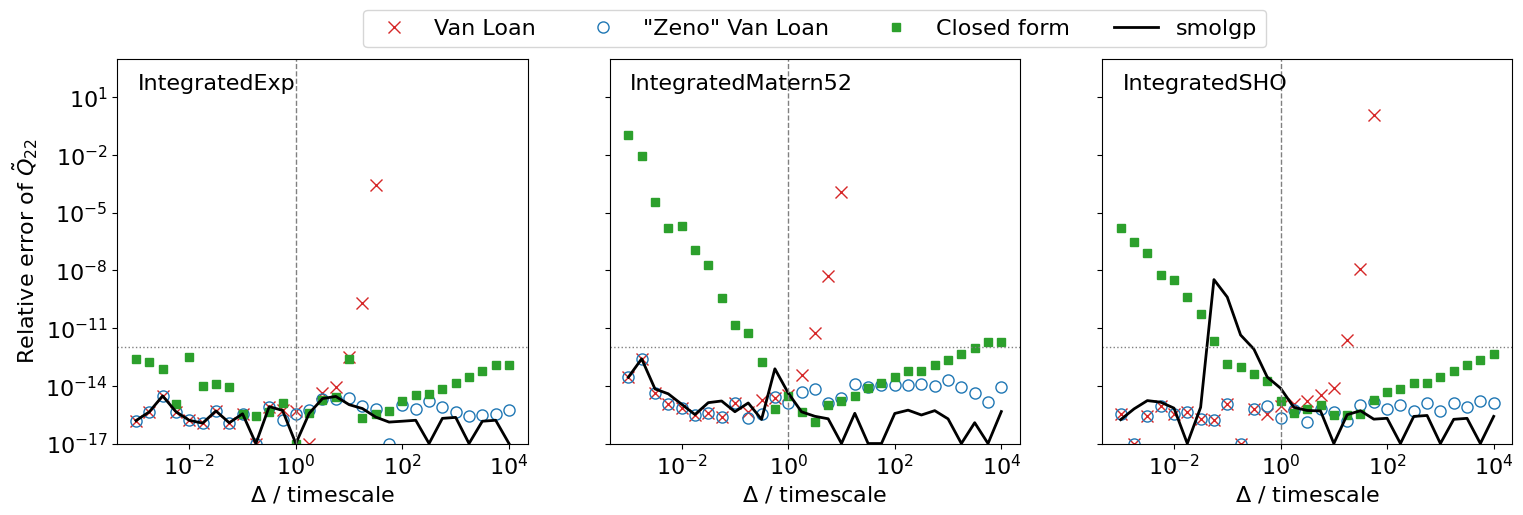

In [28]:
styles = {
    'Van Loan': {"color": "C3", "marker": "x", "ls": "none", "ms": 8},
    '"Zeno" Van Loan': {"color": "C0", "marker": "o", "ls": "none", "mfc": "none", "ms": 8},
    'Closed form': {"color": "C2", "marker": "s", "ls": "none", "ms": 6},
    'smolgp': {"color": "k", "lw": 2},
}
fig, axes = plt.subplots(1, len(kernels), figsize=(18, 5), sharey=True)
for ax, (kname, errs) in zip(axes, errors.items()):
    for mname, err in errs.items():
        ax.plot(dts, np.maximum(err, 1e-17), label=mname, **styles[mname])
    ax.axhline(1e-12, color="gray", lw=1, ls=":")
    ax.axvline(1.0, color="gray", lw=1, ls="--")
    ax.annotate(kname, xy=(0.05, 0.92), xycoords="axes fraction", ha="left", fontsize=16)
    ax.set(xscale="log", yscale="log", ylim=(1e-17, 1e3), xlabel=r"$\Delta$ / timescale")
axes[0].set_ylabel(r"Relative error of $\tilde Q_{22}$")
leg = axes[1].legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, 1))
# leg.set_in_layout(False)
# fig.tight_layout(rect=(0, 0, 1, 0.9))
# fig.tight_layout()

The dashed line marks one timescale, where `smolgp` switches from Van Loan to the closed form.

- **Van Loan** is accurate for short steps, but fails beyond a few to a few hundred timescales.
- **The closed form** is accurate for long steps, but loses precision for short ones, worst for
  the smoothest kernel (Matérn-5/2).
- **`smolgp`** combines the best of both worlds, and for `IntegratedExp` and `IntegratedMatern52` it is accurate everywhere.
  For `IntegratedSHO` it uses the hand-derived form (Eqs. B19-B20) down to $0.05$ timescales, where that form starts to have its own short-step cancellation issues (hence the bump between $0.05$ and $\sim 0.3$ timescales). This trades a little accuracy for speed there, since the hand-derived form needs no matrix exponential.
- **"Zeno" Van Loan** is also accurate everywhere, but costs more per step (below).

### Cost per step

Here we run a quick timing test under `jax.vmap` (which is how we precompute these matrices for all timesteps) for each method for 9000 steps of an `IntegratedMatern52` kernel.

In [29]:
kernel = kernels["IntegratedMatern52"]
steps = jnp.tile(jnp.array([0.02, 0.05, 30.0]), 3000)

def zeno_fixed(dt, max_doublings=32):
    # A jittable doubling: a fixed number of iterations, as it must be under vmap
    F, L, Qc = augmented(kernel)
    n = jnp.ceil(jnp.log2(jnp.maximum(jnp.abs(F).sum(0).max() * dt, 1.0)))
    h = dt * 2.0**-n
    A, Q = expm(F * h), Q_from_VanLoan(F, L, Qc, h)

    def step(i, AQ):
        A, Q = AQ
        return jax.lax.cond(i < n, lambda AQ: (AQ[0] @ AQ[0], AQ[1] + AQ[0] @ AQ[1] @ AQ[0].T),
                            lambda AQ: AQ, (A, Q))

    return jax.lax.fori_loop(0, max_doublings, step, (A, Q))[1]


timed = {
    "Van Loan": lambda dt: vanloan(kernel, dt),
    '"Zeno" Van Loan': zeno_fixed,
    "Closed form": lambda dt: stationary_closed_form(kernel, dt),
    "smolgp": lambda dt: smolgp_hybrid(kernel, dt),
}
for name, f in timed.items():
    g = jax.jit(jax.vmap(f))
    jax.block_until_ready(g(steps))
    best = np.inf
    for _ in range(5):
        t0 = time.perf_counter()
        jax.block_until_ready(g(steps))
        best = min(best, time.perf_counter() - t0)
    print(f"{name:25s} {1e3 * best:6.1f} ms")

Van Loan                    10.0 ms
"Zeno" Van Loan            123.7 ms
Closed form                 18.9 ms
smolgp                      12.2 ms


Under `vmap`, every step has to pay for both branches of `smolgp`'s switch. In the integrated Kalman filter the process noise is instead built with `jax.lax.map`, so each step pays only for its own branch.

# Writing your own integrated kernel

A new integrated kernel only needs a base `StateSpaceModel` (with a stationary covariance) and a `rate`,
the inverse of its shortest timescale. If its states are not time derivatives of each other (the default
assumption), also override `state_scales`. Everything above then works automatically. If you can derive
$\bar\Phi$ or $\tilde Q$ by hand, override `integrated_transition_matrix` or `integrated_process_noise`, and
fall back to `IntegratedStateSpaceModel.integrated_process_noise` wherever your form is not accurate, as
`IntegratedSHO` does for very short steps.